In [1]:
%pip install pandas numpy torch scikit-learn joblib matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
import matplotlib.pyplot as plt
from collections import deque
import sys

# Ana dizindeki config.py dosyamıza erişmek için
sys.path.append('.')
from config import DATA_PATH, WINDOW_SIZE

# Notebook için eksik kalmış olabilecek config sabitlerini burada tanımlıyoruz
NUM_ANGLES = 10
NUM_FEATURES = NUM_ANGLES * 2  # 10 açı + 10 açısal hız = 20
INPUT_SIZE = NUM_FEATURES * WINDOW_SIZE  # 20 * 15 = 300 nöron
NUM_CLASSES = 4 # Aparkat, Direkt, Kroşe, Savunma

print(f"Input Size: {INPUT_SIZE} | Num Classes: {NUM_CLASSES}")

Input Size: 300 | Num Classes: 4


In [3]:
print(f"Veri okunuyor: {DATA_PATH}")
df = pd.read_csv(DATA_PATH)

# Sütun sırasını canlı kamera (inference) ile BİREBİR aynı olacak şekilde zorluyoruz!
angle_cols = [f'a{i}' for i in range(10)]
vel_cols = [f'v{i}' for i in range(10)]
feature_cols = angle_cols + vel_cols # Önce açılar, sonra hızlar (Blok Formatı)

def create_windows_fixed(dataframe, window_size):
    X_list, y_list = [], []
    labels = dataframe['label'].unique()
    
    for label in labels:
        grup = dataframe[dataframe['label'] == label].copy()
        
        # DataFrame'den sadece belirlediğimiz SIRALI özellikleri alıyoruz
        grup_features = grup[feature_cols].values
        
        for i in range(len(grup_features) - window_size + 1):
            window = grup_features[i : i + window_size]
            X_list.append(window.flatten())
            y_list.append(label)
            
    return np.array(X_list), np.array(y_list)

X, y = create_windows_fixed(df, WINDOW_SIZE)
print(f"Dataset Shape: X={X.shape}, y={y.shape}")

Veri okunuyor: boks_ustgovde_aci_veri.csv
Dataset Shape: X=(8411, 300), y=(8411,)


In [4]:
# Veriyi %80 Eğitim, %20 Doğrulama (Test) olarak bölüyoruz. 
# stratify=y parametresi her sınıftan eşit oranda alınmasını sağlar.
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardizasyon (Ölçeklendirme)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Canlı kamerada tahmin yaparken de aynı ölçeklendirmeyi kullanmak için Scaler'ı diske kaydediyoruz!
joblib.dump(scaler, 'scaler.pkl')

print("✅ scaler.pkl başarıyla kaydedildi!")
print(f"Eğitim Seti (Train): {X_train_scaled.shape[0]} örnek")
print(f"Doğrulama Seti (Val): {X_val_scaled.shape[0]} örnek")

✅ scaler.pkl başarıyla kaydedildi!
Eğitim Seti (Train): 6728 örnek
Doğrulama Seti (Val): 1683 örnek


In [5]:
# NumPy dizilerini PyTorch Tensörlerine çeviriyoruz
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.LongTensor(y_train)
X_val_tensor = torch.FloatTensor(X_val_scaled)
y_val_tensor = torch.LongTensor(y_val)

# DataLoader'ları oluştur (Model verileri 64'erli paketler halinde yiyecek)
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# İşte Şampiyonumuz: 3 Katmanlı Hafif ve Hızlı Boksör Ağı (MLP)
class BoxingMLP(nn.Module):
    def __init__(self, input_size, num_classes):
        super(BoxingMLP, self).__init__()
        # 300 Nöron (Giriş: 15 frame x 20 özellik)
        self.layer1 = nn.Linear(input_size, 128)
        self.relu = nn.ReLU()
        # Dropout: Modelin ezberlemesini önler (Nöronların %30'unu rastgele kapatır)
        self.dropout = nn.Dropout(0.3)
        self.layer2 = nn.Linear(128, 64)
        # Çıkış Katmanı (4 Sınıf: Aparkat, Direkt, Kroşe, Savunma)
        self.out = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.dropout(x)
        x = self.relu(self.layer2(x))
        x = self.out(x)
        return x

print("✅ Veriler PyTorch Tensörlerine çevrildi ve BoxingMLP mimarisi tanımlandı!")

✅ Veriler PyTorch Tensörlerine çevrildi ve BoxingMLP mimarisi tanımlandı!


In [6]:
import time

# Modeli ayağa kaldır, Hatayı (Loss) ve Öğrenme Hızını (Optimizer) belirle
model = BoxingMLP(INPUT_SIZE, NUM_CLASSES)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 50
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

print("🔥 Model Eğitimi Başlıyor! Lütfen bekleyin...")
start_time = time.time()

for epoch in range(epochs):
    # --- EĞİTİM AŞAMASI (TRAIN) ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()         # Eski hatayı sıfırla
        outputs = model(X_batch)      # Modeli tahmin yapmaya zorla
        loss = criterion(outputs, y_batch) # Tahminle gerçek etiket arasındaki hatayı bul
        loss.backward()               # Hatayı nöronlara geriye doğru dağıt (Backpropagation)
        optimizer.step()              # Ağırlıkları güncelle (Öğren)
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()
        
    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(100 * correct / total)

    # --- DOĞRULAMA AŞAMASI (VALIDATION) ---
    # Model test setinde kopya çekmeden başarısını kanıtlıyor
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += y_batch.size(0)
            val_correct += (predicted == y_batch).sum().item()
            
    val_losses.append(val_loss / len(val_loader))
    val_acc = 100 * val_correct / val_total
    val_accuracies.append(val_acc)
    
    # Sadece her 5 epoch'ta bir bilgi ver (ekran kalabalık olmasın)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_losses[-1]:.4f} | Val Acc: %{val_acc:.2f}")

gecen_sure = time.time() - start_time
print(f"\n✅ Eğitim {gecen_sure:.1f} saniyede tamamlandı! Final Başarısı (Accuracy): %{val_accuracies[-1]:.2f}")

# Eğitilen şampiyonu diske kaydet!
torch.save(model.state_dict(), 'boxing_mlp_model.pth')
print("💾 Model 'boxing_mlp_model.pth' olarak kaydedildi.")

🔥 Model Eğitimi Başlıyor! Lütfen bekleyin...
Epoch [5/50] | Train Loss: 0.1762 | Val Acc: %94.89
Epoch [10/50] | Train Loss: 0.0950 | Val Acc: %96.97
Epoch [15/50] | Train Loss: 0.0681 | Val Acc: %97.50
Epoch [20/50] | Train Loss: 0.0451 | Val Acc: %98.28
Epoch [25/50] | Train Loss: 0.0374 | Val Acc: %98.28
Epoch [30/50] | Train Loss: 0.0322 | Val Acc: %99.17
Epoch [35/50] | Train Loss: 0.0277 | Val Acc: %98.57
Epoch [40/50] | Train Loss: 0.0178 | Val Acc: %99.23
Epoch [45/50] | Train Loss: 0.0229 | Val Acc: %99.05
Epoch [50/50] | Train Loss: 0.0196 | Val Acc: %99.11

✅ Eğitim 11.9 saniyede tamamlandı! Final Başarısı (Accuracy): %99.11
💾 Model 'boxing_mlp_model.pth' olarak kaydedildi.


In [7]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


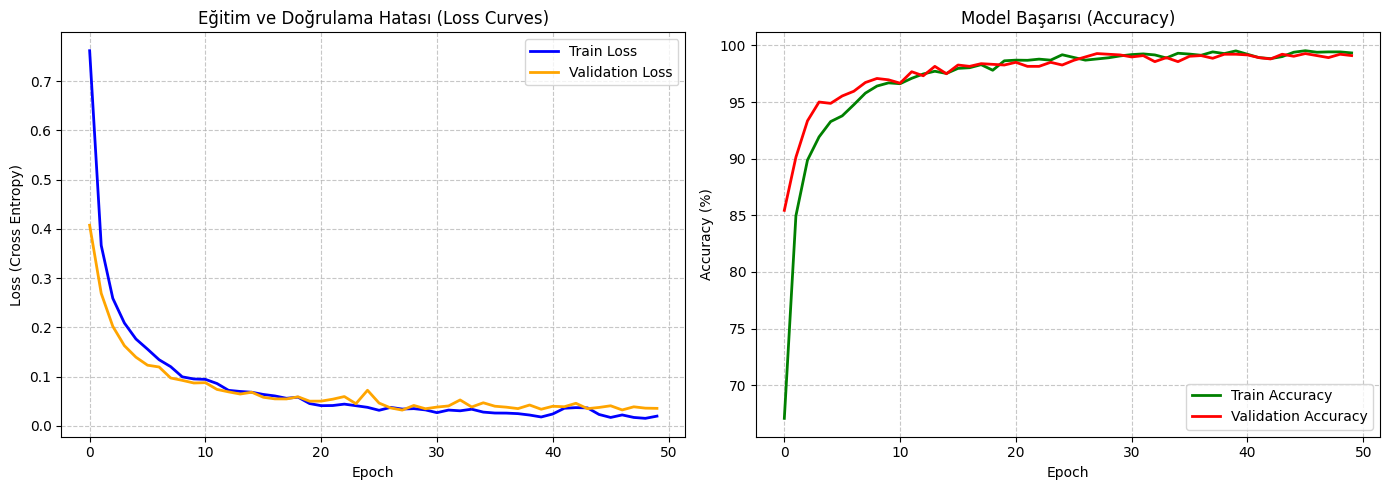

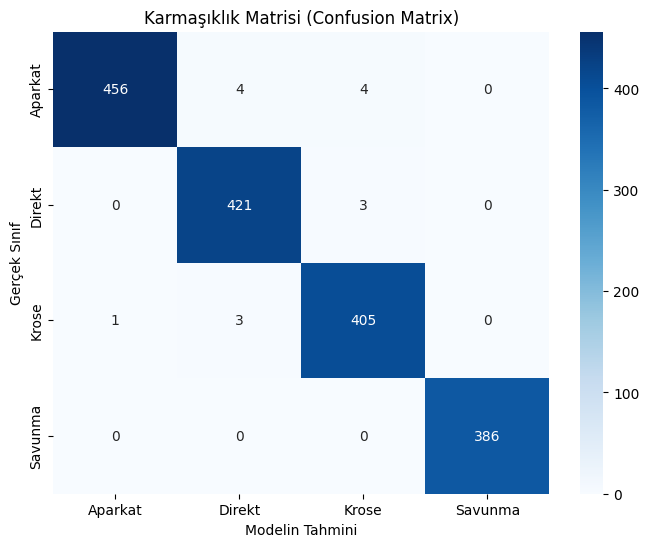


--- DETAYLI SINIFLANDIRMA RAPORU ---
              precision    recall  f1-score   support

     Aparkat       1.00      0.98      0.99       464
      Direkt       0.98      0.99      0.99       424
       Krose       0.98      0.99      0.99       409
     Savunma       1.00      1.00      1.00       386

    accuracy                           0.99      1683
   macro avg       0.99      0.99      0.99      1683
weighted avg       0.99      0.99      0.99      1683



In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ÇÖZÜM: config.py dosyasından SINIFLAR'ı içeri aktarıyoruz
from config import SINIFLAR 

# 1. KAYIP (LOSS) VE BAŞARI (ACCURACY) GRAFİKLERİ
plt.figure(figsize=(14, 5))

# Kayıp (Loss) Eğrisi
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='orange', linewidth=2)
plt.title('Eğitim ve Doğrulama Hatası (Loss Curves)')
plt.xlabel('Epoch')
plt.ylabel('Loss (Cross Entropy)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Başarı (Accuracy) Eğrisi
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy', color='green', linewidth=2)
plt.plot(val_accuracies, label='Validation Accuracy', color='red', linewidth=2)
plt.title('Model Başarısı (Accuracy)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=300)
plt.show()

# 2. CONFUSION MATRIX (KARMAŞIKLIK MATRİSİ)
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        outputs = model(X_batch)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.numpy())
        all_labels.extend(y_batch.numpy())

# Sınıf isimlerini al
class_names = [SINIFLAR[i] for i in range(NUM_CLASSES)]

# Matrisi Çiz
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Karmaşıklık Matrisi (Confusion Matrix)')
plt.ylabel('Gerçek Sınıf')
plt.xlabel('Modelin Tahmini')
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

# Detaylı Sınıflandırma Raporu
print("\n--- DETAYLI SINIFLANDIRMA RAPORU ---")
print(classification_report(all_labels, all_preds, target_names=class_names))